# Reduced SNR — All Severity Variants (v1–v5)

Evaluates the trained v3 model on **all 5 severity variants** of this degradation method.
One CSV per variant is written to `RUN_DIR/test_eval/` for the Mixed Effects Model.

| Cell | Description |
|------|-------------|
| 1 | Imports, helpers, metric functions |
| 2 | `run_eval_and_viz()` — full evaluation pipeline |
| 3 | **Run all variants** — loops v1–v5, writes CSVs, builds `datasets` dict |
| 4 | `pretty_violins_from_datasets()` — violin plot function |
| 5 | Plot severity gradient violins |

> Run cells in order. Cell 3 skips any variant whose images have not been generated yet.

In [4]:
# ===== Cell 1: imports & helpers =====
from pathlib import Path
import importlib.util, json, time, math, csv, re
from typing import Tuple, Dict, Any, List, Optional
import numpy as np
import nibabel as nib

import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
from scipy.ndimage import binary_erosion, distance_transform_edt

# ---------- Metrics ----------
def dice_soft(y: np.ndarray, p: np.ndarray) -> float:
    y = y.astype(np.float64); p = p.astype(np.float64)
    inter = (y * p).sum()
    return float((2.0 * inter) / (y.sum() + p.sum() + 1e-12))

def dice_hard(ybin: np.ndarray, pbin: np.ndarray) -> float:
    ybin = ybin.astype(np.float64); pbin = pbin.astype(np.float64)
    inter = (ybin * pbin).sum()
    return float((2.0 * inter) / (ybin.sum() + pbin.sum() + 1e-12))

def precision_recall(ybin: np.ndarray, pbin: np.ndarray):
    tp = float((ybin & pbin).sum())
    fp = float((~ybin & pbin).sum())
    fn = float((ybin & ~pbin).sum())
    prec = tp / (tp + fp + 1e-12)
    rec  = tp / (tp + fn + 1e-12)
    return float(prec), float(rec)

# ---------- Surface distances ----------
def _surface(mask: np.ndarray) -> np.ndarray:
    s = np.ones((3,3,3), dtype=bool)
    er = binary_erosion(mask.astype(bool), structure=s, border_value=0)
    return mask.astype(bool) & (~er)

def _directed_surface_distances(A_surf: np.ndarray, B_surf: np.ndarray, spacing):
    if not A_surf.any():
        return np.empty((0,), dtype=np.float64)
    edt = distance_transform_edt(~B_surf, sampling=spacing)
    return edt[A_surf]

def hd_assd(ybin: np.ndarray, pbin: np.ndarray, spacing=(1.0,1.0,1.0)) -> Dict[str, float]:
    ysurf = _surface(ybin); psurf = _surface(pbin)
    if (not ysurf.any()) or (not psurf.any()):
        return {"hd": float("nan"), "hd95": float("nan"), "assd": float("nan")}
    dY = _directed_surface_distances(ysurf, psurf, spacing)
    dP = _directed_surface_distances(psurf, ysurf, spacing)
    both = np.concatenate([dY, dP]) if (dY.size and dP.size) else np.array([], float)
    hd   = float(np.max(both)) if both.size else float("nan")
    hd95 = float(np.percentile(both, 95)) if both.size else float("nan")
    assd = float((dY.mean() + dP.mean()) / 2.0) if (dY.size and dP.size) else float("nan")
    return {"hd": hd, "hd95": hd95, "assd": assd}

# ---------- Key normalization ----------
def _norm_key(name: str) -> str:
    n = re.sub(r"\.nii(\.gz)?$", "", name or "")
    n = re.sub(r"_T1w", "", n)
    n = re.sub(r"_MNI_norm", "", n)
    n = re.sub(r"_lesion_mask(_MNI)?_clean", "", n)
    n = re.sub(r"_(soft|hard)$", "", n)
    return n

# ---------- Plotting utilities ----------
def _dropna(a):
    a = np.asarray(a, float)
    return a[~np.isnan(a)]

def _robust_limits_log(arr):
    arr = _dropna(arr)
    if arr.size == 0:
        return (1e-2, 1.0)
    lo = np.percentile(arr, 5)
    hi = np.percentile(arr, 95)
    lo = max(lo, 1e-2)
    hi = max(hi, lo * 1.5)
    return (lo, hi)

def violin(ax, data_seq, labels, y_label=None, ylim=None, log=False, title=None):
    # Always use numeric x positions to avoid categorical converter issues.
    clean = [_dropna(x) for x in data_seq]
    nonempty = [x if x.size else np.array([np.nan]) for x in clean]
    pos = np.arange(1, len(nonempty) + 1, dtype=float)
    parts = ax.violinplot(nonempty, positions=pos, showmeans=True, showmedians=True, widths=0.8)
    for b in parts.get('bodies', []):
        b.set_alpha(0.6)
    if parts.get('cmeans') is not None: parts['cmeans'].set_linewidth(1.5)
    if parts.get('cmedians') is not None: parts['cmedians'].set_linewidth(1.5)
    ax.set_xticks(pos)
    ax.set_xticklabels(labels, rotation=0)
    if y_label: ax.set_ylabel(y_label)
    if log: ax.set_yscale("log")
    if ylim: ax.set_ylim(*ylim)
    elif not log: ax.set_ylim(0, 1.0)
    if title: ax.set_title(title)
    ax.grid(True, axis='y', alpha=0.2)

def composite_figure(per_case_rows: List[Dict[str, Any]], summary: Dict[str, Any], title="Held-out evaluation"):
    # pull arrays
    soft = np.array([r["soft_dice"] for r in per_case_rows], float)
    hard_key = next((k for k in per_case_rows[0].keys() if k.startswith("hard_dice_at_")), "hard_dice_at_0.50")
    hard = np.array([r[hard_key] for r in per_case_rows], float)
    prec = np.array([r["precision"] for r in per_case_rows], float)
    rec  = np.array([r["recall"] for r in per_case_rows], float)
    hd   = np.array([r["hd"] for r in per_case_rows], float)
    hd95 = np.array([r["hd95"] for r in per_case_rows], float)
    assd = np.array([r["assd"] for r in per_case_rows], float)

    fig = plt.figure(figsize=(10,8))
    gs = GridSpec(2, 1, height_ratios=[3,2], hspace=0.35)
    ax_top = fig.add_subplot(gs[0])
    ax_bot = fig.add_subplot(gs[1])

    # Top: Dice/PR violins
    violin(ax_top, [soft, hard, prec, rec],
           ["Soft Dice", "Hard Dice", "Precision", "Recall"],
           y_label="Value", title="Per-case distributions (Dice / Precision / Recall)")

    # Inset summary bars (numeric x positions)
    inset = ax_top.inset_axes([0.62, 0.55, 0.35, 0.38])
    bar_labels = ["Macro soft", "Macro hard", "Micro soft", "Micro hard"]
    bar_vals   = [summary["macro_soft"], summary["macro_hard"], summary["micro_soft"], summary["micro_hard"]]
    x = np.arange(len(bar_labels), dtype=float)
    inset.bar(x, bar_vals)
    inset.set_ylim(0, 1.0)
    inset.set_xticks(x)
    inset.set_xticklabels(bar_labels, rotation=20, ha='right', fontsize=8)
    inset.set_title("Summary Dice", fontsize=9)
    inset.grid(True, axis='y', alpha=0.2)

    # Bottom: distance violins (log scale, robust ylim)
    all_dist = np.concatenate([_dropna(hd), _dropna(hd95), _dropna(assd)]) if (
        np.isfinite(hd).any() or np.isfinite(hd95).any() or np.isfinite(assd).any()
    ) else np.array([1.0])
    ylim = _robust_limits_log(all_dist)
    violin(ax_bot, [hd, hd95, assd],
           ["HD", "HD95", "ASSD"],
           y_label="Distance (log scale; see units in summary)",
           ylim=ylim, log=True, title="Surface distance metrics (per-case)")

    fig.suptitle(title, y=0.99, fontsize=14)
    plt.tight_layout()
    return fig


In [5]:
# ===== Cell 2: end-to-end evaluation & save =====
def run_eval_and_viz(
    RUN_DIR: Path,
    TEST_DIR: Path,
    TRAIN_MOD_PATH: Path,
    T1_DIR: Optional[Path] = None,
    MSK_DIR: Optional[Path] = None,
    MANIFEST_CSV: Optional[Path] = None,
    TH: float = 0.50,
    save_prefix: str = "test",
    dataset_tag: str = "hires"
):
    # ---- import training module ----
    spec = importlib.util.spec_from_file_location("arc_seg_train", TRAIN_MOD_PATH)
    seg = importlib.util.module_from_spec(spec)
    spec.loader.exec_module(seg)

    T1_DIR = T1_DIR or (TEST_DIR / "t1")
    MSK_DIR = MSK_DIR or (TEST_DIR / "masks")

    # ---- load model ----
    models_dir     = RUN_DIR / "models"
    callbacks_dir  = RUN_DIR / "callbacks"
    full_models    = sorted(models_dir.glob("*.keras"))
    best_weights   = callbacks_dir / "best_model_dynamic.weights.h5"
    cfg_json_path  = models_dir / "config.json"
    custom_objects = {
        "ResidualConvBlock": seg.ResidualConvBlock,
        "VisionMambaBlock": seg.VisionMambaBlock,
        "SAM2Attention": seg.SAM2Attention,
        "CombinedLoss": seg.CombinedLoss,
        "dice_coefficient": seg.dice_coefficient,
        "dice_loss": seg.dice_loss,
        "boundary_loss": seg.boundary_loss,
    }
    try:
        from keras.saving import load_model as keras_load_model
    except Exception:
        from tensorflow.keras.models import load_model as keras_load_model

    if full_models:
        model_path = full_models[-1]
        print(f"Loading FULL model: {model_path}")
        model = keras_load_model(model_path, compile=False, custom_objects=custom_objects)
        INPUT_SHAPE = tuple(model.input_shape[1:])
    else:
        assert cfg_json_path.exists(), f"Missing {cfg_json_path}"
        with open(cfg_json_path) as f:
            saved_cfg = json.load(f)
        cfg = seg.DynamicTrainingConfig(
            DATA_DIR=TEST_DIR, MODEL_DIR=models_dir, CALLBACKS_DIR=callbacks_dir,
            INPUT_SHAPE=tuple(saved_cfg["INPUT_SHAPE"]) if saved_cfg.get("INPUT_SHAPE") else None,
            BASE_FILTERS=int(saved_cfg.get("BASE_FILTERS", 8)),
            SAM_HEADS=int(saved_cfg.get("SAM_HEADS", 2)),
        )
        if not cfg.INPUT_SHAPE:
            raise RuntimeError("INPUT_SHAPE missing in saved config; cannot rebuild model.")
        INPUT_SHAPE = cfg.INPUT_SHAPE
        print("Rebuilding model from config.json and loading best weights…")
        model = seg.build_dynamic_model(cfg)
        model.load_weights(str(best_weights))

    print("INPUT_SHAPE:", INPUT_SHAPE)

    # ---- dataset ----
    if T1_DIR.exists() and MSK_DIR.exists():
        cfg_eval = seg.DynamicTrainingConfig(DATA_DIR=TEST_DIR, IMAGES_DIR=T1_DIR, MASKS_DIR=MSK_DIR,
                                             MODEL_DIR=RUN_DIR/"_tmp_models", CALLBACKS_DIR=RUN_DIR/"_tmp_callbacks")
    else:
        cfg_eval = seg.DynamicTrainingConfig(DATA_DIR=TEST_DIR,
                                             MODEL_DIR=RUN_DIR/"_tmp_models", CALLBACKS_DIR=RUN_DIR/"_tmp_callbacks")
    cfg_eval.INPUT_SHAPE = INPUT_SHAPE
    pairs, lesion_presence = seg.load_generic_dataset(cfg_eval)
    print(f"Pairs: {len(pairs)} | % non-empty masks: {lesion_presence.mean()*100:.1f}%")

    # ---- spacing inference (best-effort) ----
    use_mm = True
    spacing = (1.0, 1.0, 1.0)
    try:
        z = nib.load(str(pairs[0][0])).header.get_zooms()[:3]
        if any(abs(zi - 1.0) > 0.05 for zi in z):
            use_mm = False
    except Exception:
        use_mm = False

    # ---- quality metrics computed on each degraded image (not borrowed from base manifest) ----
    from scipy.ndimage import laplace

    def _q_zscore_in_brain(vol: np.ndarray):
        m = vol != 0
        out = np.zeros_like(vol, dtype=np.float32)
        if m.any():
            vv = vol[m].astype(np.float32)
            sd = float(vv.std())
            sd = sd if sd > 0 else 1.0
            out[m] = (vv - float(vv.mean())) / sd
        return out, m

    def _q_fwhm_gaussian_acf(img: np.ndarray, mask: np.ndarray, shifts=(1, 2, 3), max_fwhm_mm=50.0, min_pairs=1000):
        cors = []
        for sh in shifts:
            for axis in (0, 1, 2):
                sf = [slice(None)] * 3
                sg = [slice(None)] * 3
                sf[axis] = slice(0, -sh)
                sg[axis] = slice(sh, None)
                f = img[tuple(sf)]
                g = img[tuple(sg)]
                m = mask[tuple(sf)] & mask[tuple(sg)]
                if int(m.sum()) < min_pairs:
                    continue
                fv = f[m] - float(f[m].mean())
                gv = g[m] - float(g[m].mean())
                sd = float(fv.std()) * float(gv.std())
                if sd <= 1e-8:
                    continue
                r = float((fv * gv).mean() / sd)
                r = max(min(r, 0.999), 1e-6)
                cors.append((sh, r))
        if not cors:
            return float("nan")

        by_shift = {}
        for sh, rr in cors:
            by_shift.setdefault(sh, []).append(rr)
        s2 = np.array(sorted(by_shift), dtype=float) ** 2
        R = np.array([np.mean(by_shift[sh]) for sh in sorted(by_shift)], dtype=float)
        lnR = np.log(R)
        if not np.all(np.isfinite(lnR)):
            return float("nan")

        A = np.vstack([np.ones_like(s2), s2]).T
        _, b = np.linalg.lstsq(A, lnR, rcond=None)[0]
        if (not np.isfinite(b)) or b >= -1e-6:
            return float("nan")

        sigma = np.sqrt(-1.0 / (2.0 * b))
        fwhm = 2.355 * sigma
        if (not np.isfinite(fwhm)) or fwhm <= 0 or fwhm > max_fwhm_mm:
            return float("nan")
        return float(fwhm)

    def _q_high_freq_energy_ratio(img: np.ndarray, mask: np.ndarray, cutoff=0.25):
        from numpy.fft import fftn, fftshift

        vol = np.zeros_like(img, dtype=np.float32)
        vol[mask] = img[mask]
        F = fftshift(fftn(vol))
        P = (np.abs(F) ** 2).astype(np.float64)
        tot = float(P.sum())
        if (not np.isfinite(tot)) or tot <= 1e-12:
            return float("nan")

        nx, ny, nz = img.shape
        cx, cy, cz = (np.array(img.shape) - 1) / 2.0
        x = np.arange(nx) - cx
        y = np.arange(ny) - cy
        z = np.arange(nz) - cz
        X, Y, Z = np.meshgrid(x, y, z, indexing="ij")
        rx = np.abs(X) / (nx / 2.0)
        ry = np.abs(Y) / (ny / 2.0)
        rz = np.abs(Z) / (nz / 2.0)
        r = np.sqrt((rx ** 2 + ry ** 2 + rz ** 2) / 3.0)

        hf = float(P[r >= cutoff].sum())
        return float(hf / (tot + 1e-12))

    def _q_laplacian_variance(img: np.ndarray, mask: np.ndarray):
        L = laplace(img)
        vals = L[mask]
        return float(vals.var()) if vals.size else float("nan")

    quality_by_key: Dict[str, Dict[str, float]] = {}

    # ---- eval loop ----
    macro_softs, macro_hards = [], []
    precisions, recalls = [], []
    hds, hd95s, assds = [], [], []   # <-- fixed tuple init
    s_inter_soft = np.float64(0.0); s_sumy_soft = np.float64(0.0); s_sump_soft = np.float64(0.0)

    per_case_rows = []
    for i, (img_p, msk_p) in enumerate(pairs, 1):
        img = seg._load_and_preprocess_image(str(img_p), INPUT_SHAPE[:-1]).astype(np.float32)
        y   = seg._load_and_preprocess_mask(str(msk_p),  INPUT_SHAPE[:-1]).astype(np.float32)
        x = np.zeros((1,*INPUT_SHAPE), np.float32); x[0,...,0] = img
        p  = model.predict(x, verbose=0)[0,...,0].astype(np.float32)
        pb = (p >= TH)

        ds = dice_soft(y, p)
        dh = dice_hard(y > 0.5, pb)
        yy = (y > 0.5)
        prec, rec = precision_recall(yy, pb)
        dists = hd_assd(yy, pb, spacing=spacing)

        macro_softs.append(ds); macro_hards.append(dh)
        precisions.append(prec); recalls.append(rec)
        hds.append(dists["hd"]); hd95s.append(dists["hd95"]); assds.append(dists["assd"])

        s_inter_soft += (y.astype(np.float64) * p.astype(np.float64)).sum()
        s_sumy_soft  += y.sum(dtype=np.float64)
        s_sump_soft  += p.sum(dtype=np.float64)

        # quality metrics on the current degraded image
        q_key = _norm_key(Path(img_p).stem)
        try:
            raw = nib.load(str(img_p)).get_fdata().astype(np.float32)
            zimg, qmask = _q_zscore_in_brain(raw)
            if int(qmask.sum()) >= 5000:
                q_fwhm = _q_fwhm_gaussian_acf(zimg, qmask)
                q_hfe = _q_high_freq_energy_ratio(zimg, qmask, cutoff=0.25)
                q_lvar = _q_laplacian_variance(zimg, qmask)
            else:
                q_fwhm = q_hfe = q_lvar = float("nan")
        except Exception:
            q_fwhm = q_hfe = q_lvar = float("nan")

        quality_by_key[q_key] = {
            "fwhm_mm": float(q_fwhm),
            "hi_freq_energy": float(q_hfe),
            "lap_var": float(q_lvar),
        }

        if i % 10 == 0 or i == len(pairs):
            print(f"[{i}/{len(pairs)}] soft={ds:.4f} hard@{TH:.2f}={dh:.4f} | P={prec:.3f} R={rec:.3f} | "
                  f"HD={dists['hd']:.2f} HD95={dists['hd95']:.2f} ASSD={dists['assd']:.2f}")

        per_case_rows.append({
            "dataset_tag": dataset_tag,
            "key": _norm_key(Path(img_p).stem),
            "soft_dice": float(ds),
            f"hard_dice_at_{TH:.2f}": float(dh),
            "precision": float(prec),
            "recall": float(rec),
            "hd": float(dists["hd"]),
            "hd95": float(dists["hd95"]),
            "assd": float(dists["assd"]),
            "img_path": str(img_p),
            "mask_path": str(msk_p),
        })

    # micro hard (exact)
    s_inter_hard = np.float64(0.0); s_sumy_hard  = np.float64(0.0); s_sump_hard  = np.float64(0.0)
    for img_p, msk_p in pairs:
        y = seg._load_and_preprocess_mask(str(msk_p), INPUT_SHAPE[:-1]).astype(np.float32)
        x = np.zeros((1,*INPUT_SHAPE), np.float32)
        x[0,...,0] = seg._load_and_preprocess_image(str(img_p), INPUT_SHAPE[:-1]).astype(np.float32)
        p = model.predict(x, verbose=0)[0,...,0]
        pb = (p >= TH).astype(np.float64)
        s_inter_hard += (y.astype(np.float64) * pb).sum()
        s_sumy_hard  += y.sum(dtype=np.float64)
        s_sump_hard  += pb.sum(dtype=np.float64)

    macro_soft = float(np.mean(macro_softs))
    macro_hard = float(np.mean(macro_hards))
    micro_soft = float((2.0*s_inter_soft) / (s_sumy_soft + s_sump_soft + 1e-12))
    micro_hard = float((2.0*s_inter_hard) / (s_sumy_hard + s_sump_hard + 1e-12))

    out_dir = RUN_DIR / "test_eval"; out_dir.mkdir(parents=True, exist_ok=True)
    ts = time.strftime("%Y%m%d_%H%M%S")
    csv_path  = out_dir / f"{save_prefix}_metrics_{ts}.csv"
    json_path = out_dir / f"{save_prefix}_metrics_summary_{ts}.json"
    png_path  = out_dir / f"{save_prefix}_composite_{ts}.png"

    # write CSV
    with open(csv_path, "w", newline="") as f:
        cols = list(per_case_rows[0].keys()) if per_case_rows else []
        wr = csv.DictWriter(f, fieldnames=cols)
        wr.writeheader(); wr.writerows(per_case_rows)

    summary = {
        "threshold": TH,
        "macro_soft": macro_soft, "macro_hard": macro_hard,
        "micro_soft": micro_soft, "micro_hard": micro_hard,
        "n_cases": len(pairs),
        "distance_units": "mm (assumed 1mm isotropic MNI)" if use_mm else "voxel units (spacing unknown on model grid)",
        "run_dir": str(RUN_DIR), "test_dir": str(TEST_DIR),
        "csv_path": str(csv_path)
    }
    with open(json_path, "w") as f:
        json.dump(summary, f, indent=2)

    print("\n=== SUMMARY ===")
    print(f"Macro soft Dice : {macro_soft:.4f}")
    print(f"Macro hard Dice : {macro_hard:.4f}")
    print(f"Micro soft Dice : {micro_soft:.4f}")
    print(f"Micro hard Dice : {micro_hard:.4f}")
    print(f"Per-case CSV    : {csv_path}")
    print(f"Summary  JSON   : {json_path}")

    # figure
    fig = composite_figure(per_case_rows, summary,
                           title=f"{dataset_tag}: held-out evaluation")
    fig.savefig(png_path, dpi=150, bbox_inches="tight")
    plt.show()
    print("Composite figure:", png_path)

    # Merge with manifest metadata, but ALWAYS use per-image computed quality metrics.
    merged_csv_path = None
    manifest = {}
    if MANIFEST_CSV and Path(MANIFEST_CSV).exists():
        with open(MANIFEST_CSV, newline="") as f:
            for row in csv.DictReader(f):
                k = (row.get("key") or "").strip()
                if not k:
                    for src in (row.get("t1_path"), row.get("mask_path")):
                        if src:
                            k = _norm_key(Path(src).name)
                            break
                if not k:
                    continue
                manifest[k] = row

    merged = []
    for r in per_case_rows:
        m = manifest.get(r["key"], {})
        q = quality_by_key.get(r["key"], {})
        row = {**r, **{f"mf_{kk}": vv for kk, vv in m.items()}}

        # Backfill baseline metadata if no manifest row is found.
        row.setdefault("mf_dataset", dataset_tag)
        row.setdefault("mf_key", r["key"])
        row.setdefault("mf_t1_path", r.get("img_path", ""))
        row.setdefault("mf_mask_path", r.get("mask_path", ""))
        row.setdefault("mf_bin", dataset_tag)

        # Critical fix: quality comes from degraded image, not source manifest.
        row["mf_fwhm_mm"] = float(q.get("fwhm_mm", np.nan))
        row["mf_hi_freq_energy"] = float(q.get("hi_freq_energy", np.nan))
        row["mf_lap_var"] = float(q.get("lap_var", np.nan))
        merged.append(row)

    # Recompute mf_score from the per-image quality values (dataset-level z-score sum).
    fwhm_arr = np.array([float(r.get("mf_fwhm_mm", np.nan)) for r in merged], dtype=float)
    hfe_arr  = np.array([float(r.get("mf_hi_freq_energy", np.nan)) for r in merged], dtype=float)
    lap_arr  = np.array([float(r.get("mf_lap_var", np.nan)) for r in merged], dtype=float)

    def _z(v: np.ndarray) -> np.ndarray:
        out = np.full(v.shape, np.nan, dtype=float)
        m = np.isfinite(v)
        if m.sum() == 0:
            return out
        mu = float(np.mean(v[m]))
        sd = float(np.std(v[m]))
        if sd < 1e-12:
            out[m] = 0.0
        else:
            out[m] = (v[m] - mu) / sd
        return out

    score = _z(hfe_arr) + _z(lap_arr) + _z(-fwhm_arr)
    for rr, sc in zip(merged, score):
        rr["mf_score"] = float(sc) if np.isfinite(sc) else np.nan

    if merged:
        merged_csv_path = out_dir / f"{save_prefix}_metrics_with_manifest_{ts}.csv"
        with open(merged_csv_path, "w", newline="") as f:
            wr = csv.DictWriter(f, fieldnames=list(merged[0].keys()))
            wr.writeheader()
            wr.writerows(merged)
        print("Merged CSV with manifest ->", merged_csv_path)

    return per_case_rows, summary, {"per_case_csv": csv_path, "summary_json": json_path,
                                    "figure_png": png_path, "merged_csv": merged_csv_path}


2026-04-14 12:37:16,813 - SmartSOTA_Dynamic - INFO - ✅ All imports successful
2026-04-14 12:37:16,814 - SmartSOTA_Dynamic - INFO - TensorFlow eager execution: True
2026-04-14 12:37:16,815 - SmartSOTA_Dynamic - INFO - Environment verified:
- Python 3.10.18 (main, Jun  5 2025, 13:14:17) [GCC 11.2.0]
- TensorFlow 2.20.0
- NumPy 2.2.6
- GPU devices: 1



[reducedsnr_v1] severity=1  n=138 images
Visible GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
Strategy: _DefaultDistributionStrategy
Loading FULL model: /home/rbielski/stroke_cleaned/ARC_ATLAS_Combined/ARC_ATLAS_Train_v3/runs/20260410_174944/models/smart_sota_dynamic_20260410_174944.keras


I0000 00:00:1776191836.922488 2671117 gpu_process_state.cc:208] Using CUDA malloc Async allocator for GPU: 0
I0000 00:00:1776191836.923514 2671117 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 22148 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 4090, pci bus id: 0000:41:00.0, compute capability: 8.9
2026-04-14 12:37:18,393 - SmartSOTA_Dynamic - INFO - 📚 Loading dataset (flex loader for T1w volumes)…
2026-04-14 12:37:18,394 - SmartSOTA_Dynamic - INFO - Memory at dataset_load_start: CPU=1.00GB | GPU mem tracking failed | Disk: 504.3GB free
2026-04-14 12:37:18,396 - SmartSOTA_Dynamic - INFO - 📂 Two-folder mode: images=138 (/home/rbielski/stroke_cleaned/ARC_ATLAS_Combined/A_A_Combined_Data/Downsampled_Data/ReducedSNR/t1), masks=138 (/home/rbielski/stroke_cleaned/ARC_ATLAS_Combined/A_A_Combined_Data/Downsampled_Data/ReducedSNR/masks)
2026-04-14 12:37:18,396 - SmartSOTA_Dynamic - INFO - Found 138 image files and 138 mask files


INPUT_SHAPE: (192, 224, 192, 1)


2026-04-14 12:37:52,972 - SmartSOTA_Dynamic - INFO - 📊 Created 138 image–mask pairs
2026-04-14 12:37:52,973 - SmartSOTA_Dynamic - INFO - 🧠 Lesion presence: 100.00%
2026-04-14 12:37:52,974 - SmartSOTA_Dynamic - INFO - Memory at dataset_load_end: CPU=1.01GB | GPU mem tracking failed | Disk: 504.3GB free


Pairs: 138 | % non-empty masks: 100.0%


2026-04-14 12:37:54.163038: I external/local_xla/xla/service/service.cc:163] XLA service 0x7d64f4026a70 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2026-04-14 12:37:54.163062: I external/local_xla/xla/service/service.cc:171]   StreamExecutor device (0): NVIDIA GeForce RTX 4090, Compute Capability 8.9
2026-04-14 12:37:54.243714: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2026-04-14 12:37:54.518861: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:473] Loaded cuDNN version 91001
I0000 00:00:1776191880.627731 2671992 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


[10/138] soft=0.1205 hard@0.50=0.1213 | P=0.823 R=0.065 | HD=71.48 HD95=37.13 ASSD=10.91
[20/138] soft=0.6544 hard@0.50=0.6546 | P=0.890 R=0.518 | HD=56.12 HD95=13.04 ASSD=4.39
[30/138] soft=0.5400 hard@0.50=0.5411 | P=0.832 R=0.401 | HD=87.37 HD95=18.47 ASSD=4.32
[40/138] soft=0.4398 hard@0.50=0.4394 | P=0.374 R=0.533 | HD=85.66 HD95=72.99 ASSD=10.88
[50/138] soft=0.5272 hard@0.50=0.5278 | P=0.699 R=0.424 | HD=29.97 HD95=20.05 ASSD=5.12
[60/138] soft=0.0476 hard@0.50=0.0477 | P=0.027 R=0.217 | HD=80.80 HD95=70.96 ASSD=22.81
[70/138] soft=0.3106 hard@0.50=0.3120 | P=0.599 R=0.211 | HD=38.91 HD95=25.00 ASSD=8.09
[80/138] soft=0.0053 hard@0.50=0.0053 | P=0.003 R=0.086 | HD=84.30 HD95=79.84 ASSD=29.72
[90/138] soft=0.0742 hard@0.50=0.0743 | P=0.196 R=0.046 | HD=81.44 HD95=70.16 ASSD=22.35
[100/138] soft=0.0002 hard@0.50=0.0002 | P=0.000 R=0.021 | HD=115.41 HD95=107.64 ASSD=39.97
[110/138] soft=0.3493 hard@0.50=0.3506 | P=0.957 R=0.215 | HD=5.48 HD95=4.24 ASSD=1.26
[120/138] soft=0.0073 ha

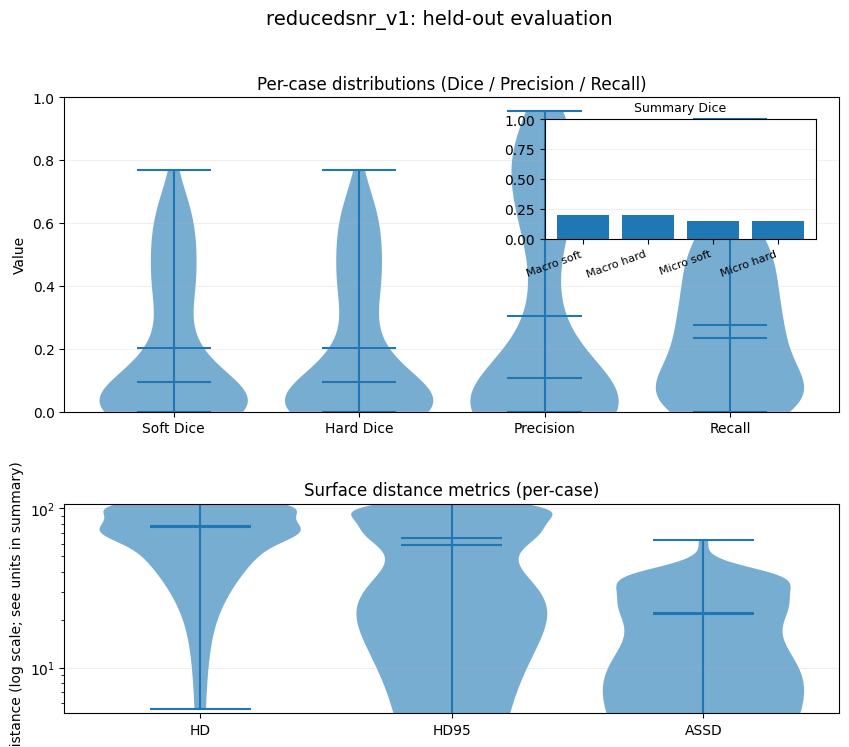

2026-04-14 12:47:19,477 - SmartSOTA_Dynamic - INFO - ✅ All imports successful
2026-04-14 12:47:19,477 - SmartSOTA_Dynamic - INFO - TensorFlow eager execution: True
2026-04-14 12:47:19,477 - SmartSOTA_Dynamic - INFO - Environment verified:
- Python 3.10.18 (main, Jun  5 2025, 13:14:17) [GCC 11.2.0]
- TensorFlow 2.20.0
- NumPy 2.2.6
- GPU devices: 1


Composite figure: /home/rbielski/stroke_cleaned/ARC_ATLAS_Combined/ARC_ATLAS_Train_v3/runs/20260410_174944/test_eval/test_reducedsnr_v1_composite_20260414_124719.png
Merged CSV with manifest -> /home/rbielski/stroke_cleaned/ARC_ATLAS_Combined/ARC_ATLAS_Train_v3/runs/20260410_174944/test_eval/test_reducedsnr_v1_metrics_with_manifest_20260414_124719.csv
Wrote summary CSV -> /home/rbielski/stroke_cleaned/ARC_ATLAS_Combined/ARC_ATLAS_Train_v3/runs/20260410_174944/test_eval/test_reducedsnr_v1_summary_stats.csv

[reducedsnr_v2] severity=2  n=138 images
Visible GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
Strategy: _DefaultDistributionStrategy
Loading FULL model: /home/rbielski/stroke_cleaned/ARC_ATLAS_Combined/ARC_ATLAS_Train_v3/runs/20260410_174944/models/smart_sota_dynamic_20260410_174944.keras


2026-04-14 12:47:20,328 - SmartSOTA_Dynamic - INFO - 📚 Loading dataset (flex loader for T1w volumes)…
2026-04-14 12:47:20,329 - SmartSOTA_Dynamic - INFO - Memory at dataset_load_start: CPU=6.97GB | GPU mem tracking failed | Disk: 504.3GB free
2026-04-14 12:47:20,331 - SmartSOTA_Dynamic - INFO - 📂 Two-folder mode: images=138 (/home/rbielski/stroke_cleaned/ARC_ATLAS_Combined/A_A_Combined_Data/Downsampled_Data/ReducedSNR_v2/t1), masks=138 (/home/rbielski/stroke_cleaned/ARC_ATLAS_Combined/A_A_Combined_Data/Downsampled_Data/ReducedSNR_v2/masks)
2026-04-14 12:47:20,331 - SmartSOTA_Dynamic - INFO - Found 138 image files and 138 mask files


INPUT_SHAPE: (192, 224, 192, 1)


2026-04-14 12:47:56,738 - SmartSOTA_Dynamic - INFO - 📊 Created 138 image–mask pairs
2026-04-14 12:47:56,739 - SmartSOTA_Dynamic - INFO - 🧠 Lesion presence: 100.00%
2026-04-14 12:47:56,739 - SmartSOTA_Dynamic - INFO - Memory at dataset_load_end: CPU=6.89GB | GPU mem tracking failed | Disk: 504.3GB free


Pairs: 138 | % non-empty masks: 100.0%
[10/138] soft=0.0103 hard@0.50=0.0103 | P=0.256 R=0.005 | HD=83.10 HD95=33.66 ASSD=17.59
[20/138] soft=0.1881 hard@0.50=0.1879 | P=0.951 R=0.104 | HD=39.26 HD95=15.68 ASSD=6.81
[30/138] soft=0.0868 hard@0.50=0.0872 | P=0.275 R=0.052 | HD=69.29 HD95=20.52 ASSD=8.81
[40/138] soft=0.0671 hard@0.50=0.0672 | P=0.113 R=0.048 | HD=89.14 HD95=23.41 ASSD=13.95
[50/138] soft=0.0026 hard@0.50=0.0024 | P=0.129 R=0.001 | HD=59.74 HD95=23.73 ASSD=14.45
[60/138] soft=0.0000 hard@0.50=0.0000 | P=0.000 R=0.000 | HD=102.84 HD95=90.26 ASSD=38.39
[70/138] soft=0.0036 hard@0.50=0.0037 | P=0.002 R=0.024 | HD=104.15 HD95=96.42 ASSD=35.63
[80/138] soft=0.0003 hard@0.50=0.0003 | P=0.000 R=0.013 | HD=90.34 HD95=83.25 ASSD=33.85
[90/138] soft=0.0028 hard@0.50=0.0028 | P=0.002 R=0.013 | HD=112.73 HD95=98.78 ASSD=37.37
[100/138] soft=0.0001 hard@0.50=0.0001 | P=0.000 R=0.016 | HD=118.49 HD95=111.67 ASSD=41.62
[110/138] soft=0.0000 hard@0.50=0.0000 | P=0.000 R=0.000 | HD=119.2

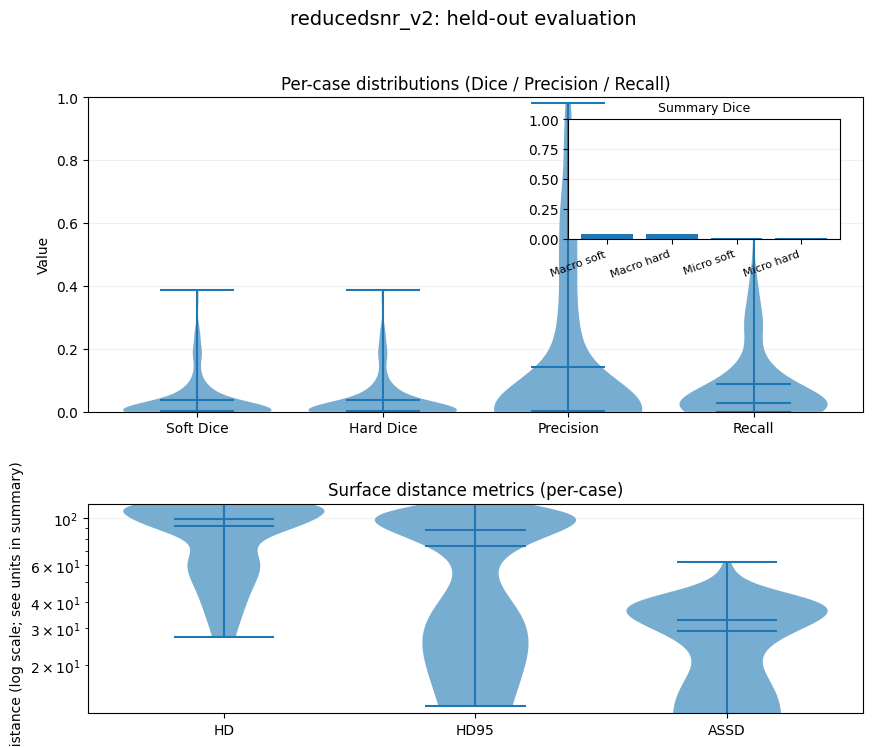

2026-04-14 12:57:34,612 - SmartSOTA_Dynamic - INFO - ✅ All imports successful
2026-04-14 12:57:34,613 - SmartSOTA_Dynamic - INFO - TensorFlow eager execution: True
2026-04-14 12:57:34,613 - SmartSOTA_Dynamic - INFO - Environment verified:
- Python 3.10.18 (main, Jun  5 2025, 13:14:17) [GCC 11.2.0]
- TensorFlow 2.20.0
- NumPy 2.2.6
- GPU devices: 1


Composite figure: /home/rbielski/stroke_cleaned/ARC_ATLAS_Combined/ARC_ATLAS_Train_v3/runs/20260410_174944/test_eval/test_reducedsnr_v2_composite_20260414_125734.png
Merged CSV with manifest -> /home/rbielski/stroke_cleaned/ARC_ATLAS_Combined/ARC_ATLAS_Train_v3/runs/20260410_174944/test_eval/test_reducedsnr_v2_metrics_with_manifest_20260414_125734.csv
Wrote summary CSV -> /home/rbielski/stroke_cleaned/ARC_ATLAS_Combined/ARC_ATLAS_Train_v3/runs/20260410_174944/test_eval/test_reducedsnr_v2_summary_stats.csv

[reducedsnr_v3] severity=3  n=138 images
Visible GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
Strategy: _DefaultDistributionStrategy
Loading FULL model: /home/rbielski/stroke_cleaned/ARC_ATLAS_Combined/ARC_ATLAS_Train_v3/runs/20260410_174944/models/smart_sota_dynamic_20260410_174944.keras


2026-04-14 12:57:35,456 - SmartSOTA_Dynamic - INFO - 📚 Loading dataset (flex loader for T1w volumes)…
2026-04-14 12:57:35,457 - SmartSOTA_Dynamic - INFO - Memory at dataset_load_start: CPU=11.14GB | GPU mem tracking failed | Disk: 504.3GB free
2026-04-14 12:57:35,459 - SmartSOTA_Dynamic - INFO - 📂 Two-folder mode: images=138 (/home/rbielski/stroke_cleaned/ARC_ATLAS_Combined/A_A_Combined_Data/Downsampled_Data/ReducedSNR_v3/t1), masks=138 (/home/rbielski/stroke_cleaned/ARC_ATLAS_Combined/A_A_Combined_Data/Downsampled_Data/ReducedSNR_v3/masks)
2026-04-14 12:57:35,460 - SmartSOTA_Dynamic - INFO - Found 138 image files and 138 mask files


INPUT_SHAPE: (192, 224, 192, 1)


2026-04-14 12:58:14,802 - SmartSOTA_Dynamic - INFO - 📊 Created 138 image–mask pairs
2026-04-14 12:58:14,802 - SmartSOTA_Dynamic - INFO - 🧠 Lesion presence: 100.00%
2026-04-14 12:58:14,803 - SmartSOTA_Dynamic - INFO - Memory at dataset_load_end: CPU=11.03GB | GPU mem tracking failed | Disk: 504.3GB free


Pairs: 138 | % non-empty masks: 100.0%
[10/138] soft=0.0000 hard@0.50=0.0000 | P=0.000 R=0.000 | HD=77.83 HD95=70.43 ASSD=37.02
[20/138] soft=0.0058 hard@0.50=0.0058 | P=0.496 R=0.003 | HD=55.03 HD95=46.28 ASSD=23.37
[30/138] soft=0.0000 hard@0.50=0.0000 | P=0.000 R=0.000 | HD=113.36 HD95=49.68 ASSD=27.86
[40/138] soft=0.0000 hard@0.50=0.0000 | P=0.000 R=0.000 | HD=88.89 HD95=31.08 ASSD=20.08
[50/138] soft=0.0000 hard@0.50=0.0000 | P=0.000 R=0.000 | HD=60.76 HD95=41.16 ASSD=20.19
[60/138] soft=0.0035 hard@0.50=0.0035 | P=0.002 R=0.042 | HD=105.20 HD95=92.52 ASSD=30.83
[70/138] soft=0.0025 hard@0.50=0.0025 | P=0.001 R=0.019 | HD=105.69 HD95=97.58 ASSD=33.77
[80/138] soft=0.0000 hard@0.50=0.0000 | P=0.000 R=0.000 | HD=95.37 HD95=85.48 ASSD=34.88
[90/138] soft=0.0020 hard@0.50=0.0020 | P=0.001 R=0.012 | HD=115.43 HD95=100.14 ASSD=35.46
[100/138] soft=0.0000 hard@0.50=0.0000 | P=0.000 R=0.000 | HD=122.71 HD95=112.78 ASSD=41.20
[110/138] soft=0.0000 hard@0.50=0.0000 | P=0.000 R=0.000 | HD=1

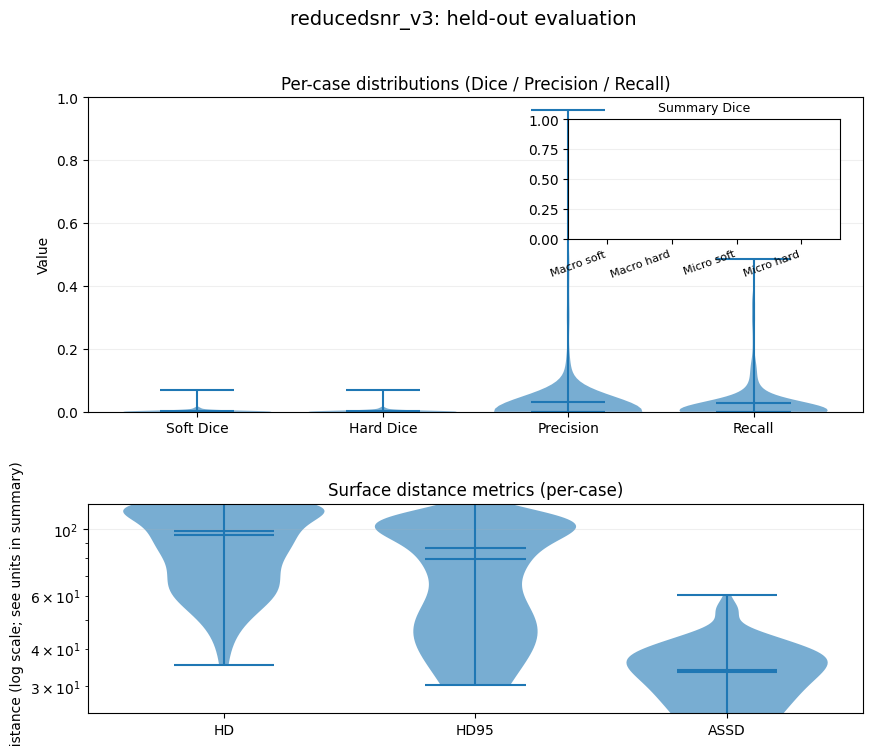

2026-04-14 13:07:50,249 - SmartSOTA_Dynamic - INFO - ✅ All imports successful
2026-04-14 13:07:50,250 - SmartSOTA_Dynamic - INFO - TensorFlow eager execution: True
2026-04-14 13:07:50,250 - SmartSOTA_Dynamic - INFO - Environment verified:
- Python 3.10.18 (main, Jun  5 2025, 13:14:17) [GCC 11.2.0]
- TensorFlow 2.20.0
- NumPy 2.2.6
- GPU devices: 1


Composite figure: /home/rbielski/stroke_cleaned/ARC_ATLAS_Combined/ARC_ATLAS_Train_v3/runs/20260410_174944/test_eval/test_reducedsnr_v3_composite_20260414_130749.png
Merged CSV with manifest -> /home/rbielski/stroke_cleaned/ARC_ATLAS_Combined/ARC_ATLAS_Train_v3/runs/20260410_174944/test_eval/test_reducedsnr_v3_metrics_with_manifest_20260414_130749.csv
Wrote summary CSV -> /home/rbielski/stroke_cleaned/ARC_ATLAS_Combined/ARC_ATLAS_Train_v3/runs/20260410_174944/test_eval/test_reducedsnr_v3_summary_stats.csv

[reducedsnr_v4] severity=4  n=138 images
Visible GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
Strategy: _DefaultDistributionStrategy
Loading FULL model: /home/rbielski/stroke_cleaned/ARC_ATLAS_Combined/ARC_ATLAS_Train_v3/runs/20260410_174944/models/smart_sota_dynamic_20260410_174944.keras


2026-04-14 13:07:51,090 - SmartSOTA_Dynamic - INFO - 📚 Loading dataset (flex loader for T1w volumes)…
2026-04-14 13:07:51,091 - SmartSOTA_Dynamic - INFO - Memory at dataset_load_start: CPU=15.28GB | GPU mem tracking failed | Disk: 504.3GB free
2026-04-14 13:07:51,093 - SmartSOTA_Dynamic - INFO - 📂 Two-folder mode: images=138 (/home/rbielski/stroke_cleaned/ARC_ATLAS_Combined/A_A_Combined_Data/Downsampled_Data/ReducedSNR_v4/t1), masks=138 (/home/rbielski/stroke_cleaned/ARC_ATLAS_Combined/A_A_Combined_Data/Downsampled_Data/ReducedSNR_v4/masks)
2026-04-14 13:07:51,093 - SmartSOTA_Dynamic - INFO - Found 138 image files and 138 mask files


INPUT_SHAPE: (192, 224, 192, 1)


2026-04-14 13:08:28,214 - SmartSOTA_Dynamic - INFO - 📊 Created 138 image–mask pairs
2026-04-14 13:08:28,214 - SmartSOTA_Dynamic - INFO - 🧠 Lesion presence: 100.00%
2026-04-14 13:08:28,215 - SmartSOTA_Dynamic - INFO - Memory at dataset_load_end: CPU=15.17GB | GPU mem tracking failed | Disk: 504.3GB free


Pairs: 138 | % non-empty masks: 100.0%
[10/138] soft=0.0000 hard@0.50=0.0000 | P=0.000 R=0.000 | HD=nan HD95=nan ASSD=nan
[20/138] soft=0.0000 hard@0.50=0.0000 | P=0.000 R=0.000 | HD=nan HD95=nan ASSD=nan
[30/138] soft=0.0000 hard@0.50=0.0000 | P=0.000 R=0.000 | HD=nan HD95=nan ASSD=nan
[40/138] soft=0.0000 hard@0.50=0.0000 | P=0.000 R=0.000 | HD=nan HD95=nan ASSD=nan
[50/138] soft=0.0000 hard@0.50=0.0000 | P=0.000 R=0.000 | HD=nan HD95=nan ASSD=nan
[60/138] soft=0.0000 hard@0.50=0.0000 | P=0.000 R=0.000 | HD=105.52 HD95=95.28 ASSD=42.04
[70/138] soft=0.0014 hard@0.50=0.0014 | P=0.001 R=0.011 | HD=106.30 HD95=98.32 ASSD=37.34
[80/138] soft=0.0000 hard@0.50=0.0000 | P=0.000 R=0.000 | HD=97.63 HD95=86.36 ASSD=35.77
[90/138] soft=0.0006 hard@0.50=0.0006 | P=0.000 R=0.004 | HD=116.73 HD95=100.51 ASSD=37.69
[100/138] soft=0.0000 hard@0.50=0.0000 | P=0.000 R=0.001 | HD=125.58 HD95=113.13 ASSD=40.06
[110/138] soft=0.0000 hard@0.50=0.0000 | P=0.000 R=0.000 | HD=124.99 HD95=116.18 ASSD=47.59
[1

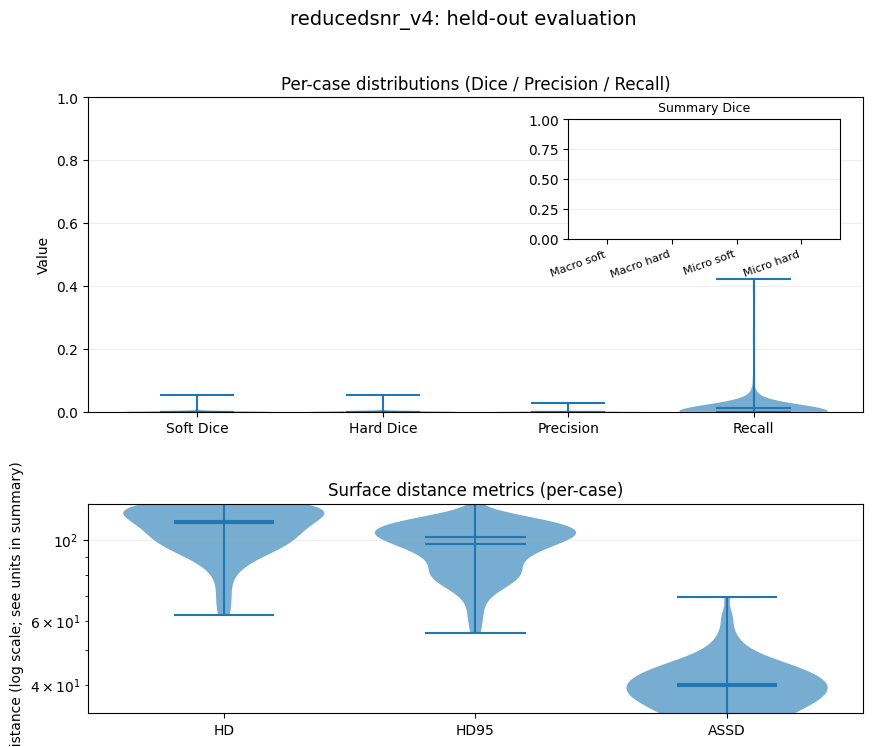

2026-04-14 13:17:13,574 - SmartSOTA_Dynamic - INFO - ✅ All imports successful
2026-04-14 13:17:13,575 - SmartSOTA_Dynamic - INFO - TensorFlow eager execution: True
2026-04-14 13:17:13,575 - SmartSOTA_Dynamic - INFO - Environment verified:
- Python 3.10.18 (main, Jun  5 2025, 13:14:17) [GCC 11.2.0]
- TensorFlow 2.20.0
- NumPy 2.2.6
- GPU devices: 1


Composite figure: /home/rbielski/stroke_cleaned/ARC_ATLAS_Combined/ARC_ATLAS_Train_v3/runs/20260410_174944/test_eval/test_reducedsnr_v4_composite_20260414_131713.png
Merged CSV with manifest -> /home/rbielski/stroke_cleaned/ARC_ATLAS_Combined/ARC_ATLAS_Train_v3/runs/20260410_174944/test_eval/test_reducedsnr_v4_metrics_with_manifest_20260414_131713.csv
Wrote summary CSV -> /home/rbielski/stroke_cleaned/ARC_ATLAS_Combined/ARC_ATLAS_Train_v3/runs/20260410_174944/test_eval/test_reducedsnr_v4_summary_stats.csv

[reducedsnr_v5] severity=5  n=138 images
Visible GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
Strategy: _DefaultDistributionStrategy
Loading FULL model: /home/rbielski/stroke_cleaned/ARC_ATLAS_Combined/ARC_ATLAS_Train_v3/runs/20260410_174944/models/smart_sota_dynamic_20260410_174944.keras


2026-04-14 13:17:14,415 - SmartSOTA_Dynamic - INFO - 📚 Loading dataset (flex loader for T1w volumes)…
2026-04-14 13:17:14,416 - SmartSOTA_Dynamic - INFO - Memory at dataset_load_start: CPU=19.42GB | GPU mem tracking failed | Disk: 504.3GB free
2026-04-14 13:17:14,418 - SmartSOTA_Dynamic - INFO - 📂 Two-folder mode: images=138 (/home/rbielski/stroke_cleaned/ARC_ATLAS_Combined/A_A_Combined_Data/Downsampled_Data/ReducedSNR_v5/t1), masks=138 (/home/rbielski/stroke_cleaned/ARC_ATLAS_Combined/A_A_Combined_Data/Downsampled_Data/ReducedSNR_v5/masks)
2026-04-14 13:17:14,418 - SmartSOTA_Dynamic - INFO - Found 138 image files and 138 mask files


INPUT_SHAPE: (192, 224, 192, 1)


2026-04-14 13:17:51,023 - SmartSOTA_Dynamic - INFO - 📊 Created 138 image–mask pairs
2026-04-14 13:17:51,024 - SmartSOTA_Dynamic - INFO - 🧠 Lesion presence: 100.00%
2026-04-14 13:17:51,025 - SmartSOTA_Dynamic - INFO - Memory at dataset_load_end: CPU=19.29GB | GPU mem tracking failed | Disk: 504.3GB free


Pairs: 138 | % non-empty masks: 100.0%
[10/138] soft=0.0000 hard@0.50=0.0000 | P=0.000 R=0.000 | HD=nan HD95=nan ASSD=nan
[20/138] soft=0.0000 hard@0.50=0.0000 | P=0.000 R=0.000 | HD=nan HD95=nan ASSD=nan
[30/138] soft=0.0000 hard@0.50=0.0000 | P=0.000 R=0.000 | HD=nan HD95=nan ASSD=nan
[40/138] soft=0.0000 hard@0.50=0.0000 | P=0.000 R=0.000 | HD=nan HD95=nan ASSD=nan
[50/138] soft=0.0000 hard@0.50=0.0000 | P=0.000 R=0.000 | HD=nan HD95=nan ASSD=nan
[60/138] soft=0.0000 hard@0.50=0.0000 | P=0.000 R=0.000 | HD=nan HD95=nan ASSD=nan
[70/138] soft=0.0000 hard@0.50=0.0000 | P=0.000 R=0.000 | HD=107.37 HD95=99.21 ASSD=50.48
[80/138] soft=0.0000 hard@0.50=0.0000 | P=0.000 R=0.000 | HD=97.58 HD95=86.84 ASSD=41.14
[90/138] soft=0.0000 hard@0.50=0.0000 | P=0.000 R=0.000 | HD=117.74 HD95=101.22 ASSD=43.26
[100/138] soft=0.0000 hard@0.50=0.0000 | P=0.000 R=0.000 | HD=126.64 HD95=113.96 ASSD=38.53
[110/138] soft=0.0000 hard@0.50=0.0000 | P=0.000 R=0.000 | HD=127.06 HD95=118.22 ASSD=64.15
[120/138]

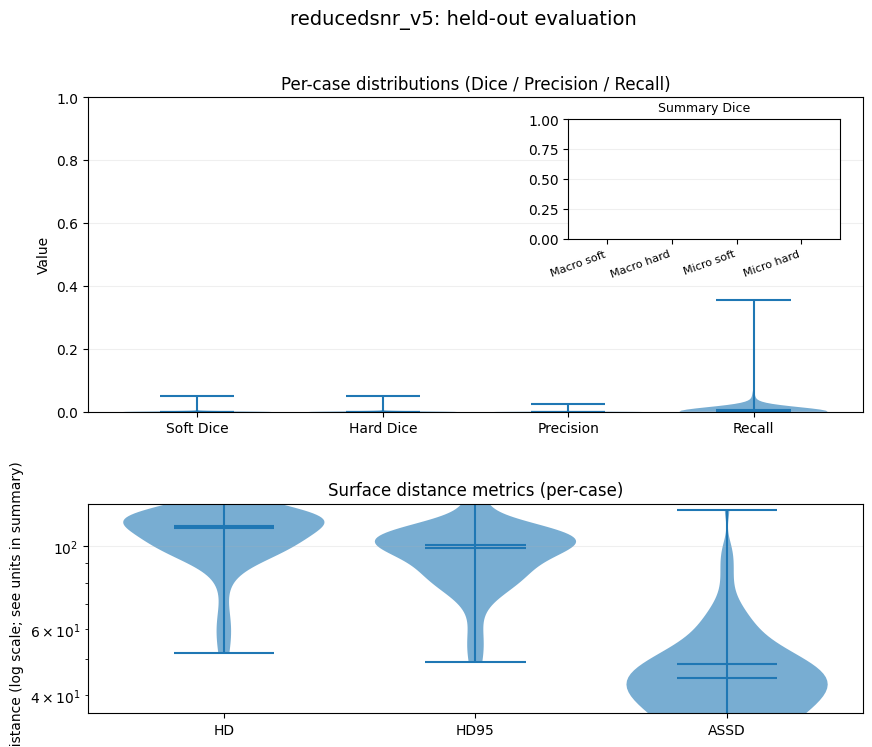

Composite figure: /home/rbielski/stroke_cleaned/ARC_ATLAS_Combined/ARC_ATLAS_Train_v3/runs/20260410_174944/test_eval/test_reducedsnr_v5_composite_20260414_132620.png
Merged CSV with manifest -> /home/rbielski/stroke_cleaned/ARC_ATLAS_Combined/ARC_ATLAS_Train_v3/runs/20260410_174944/test_eval/test_reducedsnr_v5_metrics_with_manifest_20260414_132620.csv
Wrote summary CSV -> /home/rbielski/stroke_cleaned/ARC_ATLAS_Combined/ARC_ATLAS_Train_v3/runs/20260410_174944/test_eval/test_reducedsnr_v5_summary_stats.csv

Variants evaluated: ['reducedsnr_v1', 'reducedsnr_v2', 'reducedsnr_v3', 'reducedsnr_v4', 'reducedsnr_v5']
Example row keys: ['dataset_tag', 'key', 'soft_dice', 'hard_dice_at_0.50', 'precision', 'recall', 'hd', 'hd95', 'assd', 'img_path', 'mask_path', 'severity', 'method', 'variant_id']


In [6]:
# ===== All-variants evaluation: Reduced SNR (v1–v5) =====
# Loops over all 5 severity variants, runs full evaluation for each, and
# writes one CSV per variant to RUN_DIR/test_eval/.
# Each row gets 'severity' (1–5) and 'method' columns for the Mixed Effects Model.
# Skip variants whose images have not been generated yet.
#
# MEM FILE_SPEC glob for each variant:
#   'test_reducedsnr_v1'_metrics_with_manifest_*.csv  (severity 1)
#   'test_reducedsnr_v2'_metrics_with_manifest_*.csv  (severity 2)
#   'test_reducedsnr_v3'_metrics_with_manifest_*.csv  (severity 3)
#   'test_reducedsnr_v4'_metrics_with_manifest_*.csv  (severity 4)
#   'test_reducedsnr_v5'_metrics_with_manifest_*.csv  (severity 5)

from pathlib import Path
import csv, json
import numpy as np
from typing import Dict, List, Any

# ---- helpers (NaN-safe) ----
def _dropna(a):
    a = np.asarray(a, float); return a[~np.isnan(a)]

def summarize_vector(x) -> Dict[str, float]:
    v = _dropna(np.array(x, float))
    if v.size == 0:
        return dict(n=0, mean=np.nan, median=np.nan, std=np.nan,
                    p25=np.nan, p75=np.nan, min=np.nan, max=np.nan, nan_count=len(x))
    return dict(n=int(v.size), mean=float(np.mean(v)), median=float(np.median(v)),
                std=float(np.std(v, ddof=1)) if v.size > 1 else 0.0,
                p25=float(np.percentile(v, 25)), p75=float(np.percentile(v, 75)),
                min=float(np.min(v)), max=float(np.max(v)),
                nan_count=int(len(x) - v.size))

def summarize_dataset(rows: List[Dict[str, Any]]) -> Dict[str, Any]:
    hard_key = next((k for k in rows[0].keys() if k.startswith("hard_dice_at_")), "hard_dice_at_0.50")
    return {
        "soft": summarize_vector([r["soft_dice"]  for r in rows]),
        "hard": summarize_vector([r[hard_key]     for r in rows]),
        "prec": summarize_vector([r["precision"]  for r in rows]),
        "rec":  summarize_vector([r["recall"]     for r in rows]),
        "hd":   summarize_vector([r["hd"]         for r in rows]),
        "hd95": summarize_vector([r["hd95"]       for r in rows]),
        "assd": summarize_vector([r["assd"]       for r in rows]),
    }

def write_summary_csv(summary_table: List[Dict[str, Any]], out_path: Path):
    if not summary_table: return
    keys = sorted({k for row in summary_table for k in row.keys()})
    with open(out_path, "w", newline="") as f:
        wr = csv.DictWriter(f, fieldnames=keys)
        wr.writeheader(); wr.writerows(summary_table)
    print("Wrote summary CSV ->", out_path)

# ---- Paths ----
RUN_DIR   = Path('/home/rbielski/stroke_cleaned/ARC_ATLAS_Combined/ARC_ATLAS_Train_v3/runs/20260410_174944')
TRAIN_MOD = Path('/home/rbielski/stroke_cleaned/stroke_segmentation_v1.2/stroke_seg_v1.2_train.py')
MANIFEST  = Path('/home/rbielski/stroke_cleaned/ARC_ATLAS_Combined/A_A_Combined_Data/Processed_HiresLowres_Split_Data/test_hires.csv')
DS_BASE   = Path('/home/rbielski/stroke_cleaned/ARC_ATLAS_Combined/A_A_Combined_Data/Downsampled_Data')

import os
os.environ["CUDA_VISIBLE_DEVICES"] = "0"
os.environ["TF_XLA_FLAGS"]             = ""
os.environ["TF_FORCE_GPU_ALLOW_GROWTH"] = "true"

# ---- Variant configs ----
VARIANTS = [
    {"tag": 'reducedsnr_v1', "prefix": 'test_reducedsnr_v1', "dir": DS_BASE / 'ReducedSNR', "severity": 1},
    {"tag": 'reducedsnr_v2', "prefix": 'test_reducedsnr_v2', "dir": DS_BASE / 'ReducedSNR_v2', "severity": 2},
    {"tag": 'reducedsnr_v3', "prefix": 'test_reducedsnr_v3', "dir": DS_BASE / 'ReducedSNR_v3', "severity": 3},
    {"tag": 'reducedsnr_v4', "prefix": 'test_reducedsnr_v4', "dir": DS_BASE / 'ReducedSNR_v4', "severity": 4},
    {"tag": 'reducedsnr_v5', "prefix": 'test_reducedsnr_v5', "dir": DS_BASE / 'ReducedSNR_v5', "severity": 5},
]

# ---- Run evaluation for each variant ----
datasets: Dict[str, Dict[str, Any]] = {}

for v in VARIANTS:
    t1_dir  = v["dir"] / "t1"
    msk_dir = v["dir"] / "masks"
    if not t1_dir.exists():
        print(f"[SKIP] {v['tag']}: {t1_dir} not found — run the downsampling cells first")
        continue
    n_imgs = len(list(t1_dir.glob("*.nii.gz")))
    if n_imgs == 0:
        print(f"[SKIP] {v['tag']}: directory exists but contains no .nii.gz files")
        continue
    # Skip if already completed — reload rows from cache CSV
    _done = []  # skip-cache disabled: always re-run with new model
    if _done:
        print(f"[DONE] {v['tag']}: loading from cache...")
        import csv as _csv
        _pcase = sorted((RUN_DIR / "test_eval").glob(f"{v['prefix']}_metrics_with_manifest_*.csv"))
        _rows_cached = []
        _FLOAT_COLS = {"soft_dice","precision","recall","hd","hd95","assd"}
        if _pcase:
            with open(_pcase[-1], newline="") as _f:
                for _r in _csv.DictReader(_f):
                    for _fc in _FLOAT_COLS:
                        if _fc in _r:
                            try: _r[_fc] = float(_r[_fc])
                            except (ValueError, TypeError): _r[_fc] = float("nan")
                    for _k in list(_r.keys()):
                        if _k.startswith("hard_dice"):
                            try: _r[_k] = float(_r[_k])
                            except (ValueError, TypeError): _r[_k] = float("nan")
                    _r["severity"]   = v["severity"]
                    _r["method"]     = "ReducedSNR"
                    _r["variant_id"] = v["tag"]
                    _rows_cached.append(_r)
        datasets[v["tag"]] = {
            "rows":         _rows_cached,
            "summary":      summarize_dataset(_rows_cached),
            "severity":     v["severity"],
            "source_paths": [str(_pcase[-1])] if _pcase else [],
        }
        print(f"  loaded {len(_rows_cached)} rows")
        continue
    print(f"\n[{v['tag']}] severity={v['severity']}  n={n_imgs} images")
    rows, summary, paths = run_eval_and_viz(
        RUN_DIR=RUN_DIR, TEST_DIR=v["dir"], TRAIN_MOD_PATH=TRAIN_MOD,
        T1_DIR=t1_dir, MSK_DIR=msk_dir, MANIFEST_CSV=MANIFEST,
        TH=0.50, save_prefix=v["prefix"], dataset_tag=v["tag"]
    )
    # annotate rows for MEM (severity + method columns)
    for row in rows:
        row["severity"]   = v["severity"]
        row["method"]     = 'ReducedSNR'
        row["variant_id"] = v["tag"]

    datasets[v["tag"]] = {
        "rows":         rows,
        "summary":      summarize_dataset(rows),
        "source_paths": [paths["per_case_csv"]],
        "severity":     v["severity"],
    }

    flat = {"dataset_tag": v["tag"], "severity": v["severity"], "method": 'ReducedSNR'}
    for metric, stats in datasets[v["tag"]]["summary"].items():
        for k, val in stats.items():
            flat[f"{metric}_{k}"] = val
    out_summary = Path(paths["per_case_csv"]).with_name(f"{v['prefix']}_summary_stats.csv")
    write_summary_csv([flat], out_summary)

print("\nVariants evaluated:", list(datasets.keys()))
if datasets:
    _rows_examples = [v for v in datasets.values() if v['rows']]
    if _rows_examples:
        print(f"Example row keys: {list(_rows_examples[0]['rows'][0].keys())}")
    else:
        print("(All variants loaded from cache — no new rows this run)")


In [7]:
# === Pretty grouped violins (final tweaks) ===
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
from pathlib import Path
from typing import Dict, Any, List

PALETTE       = ["#4C78A8"]      # add more colors if plotting multiple datasets
POINT_ALPHA   = 0.55
POINT_SIZE    = 10
VIOLIN_ALPHA  = 0.18             # extra transparent so dots show clearly
EDGE_ALPHA    = 0.35
ROBUST_PERC   = (5, 95)
JITTER_WIDTH  = 0.08
SEED          = 7
_rng = np.random.default_rng(SEED)

def _dropna(a):
    def _to_float(v):
        try: return float(v)
        except (TypeError, ValueError): return np.nan
    a = np.array([_to_float(v) for v in a], dtype=float)
    return a[~np.isnan(a)]

def _robust_limits_linear(arr, p=(5,95), min_span=1e-6):
    arr = _dropna(arr)
    if arr.size == 0: return (0.0, 1.0)
    lo, hi = np.percentile(arr, p[0]), np.percentile(arr, p[1])
    if hi - lo < min_span: hi = lo + min_span
    return float(lo), float(hi)

def _beeswarm_x(center: float, n: int, spread: float) -> np.ndarray:
    if n == 0: return np.array([])
    return center + _rng.normal(0.0, spread, size=n)

def _get_val(row: Dict[str, Any], key: str):
    if key == "soft": return row.get("soft", row.get("soft_dice"))
    if key == "hard":
        for k in row.keys():
            if k.startswith("hard_dice"): return row[k]
        return row.get("hard")
    if key == "prec": return row.get("prec", row.get("precision"))
    if key == "rec":  return row.get("rec",  row.get("recall"))
    return row.get(key)  # hd, hd95, assd

def pretty_violins_from_datasets(
    datasets: Dict[str, Dict[str, Any]],
    title: str = "Higher Resolution Images Test Set",
    legend_label: str = "Individual Image Segmentation",
    distance_units: str = "mm",
    save_path = None,
    show_legend = False
):
    if not datasets:
        print("No datasets to plot."); 
        return None
    

    tags = sorted(datasets.keys())

    def metric_arrays(std_key: str) -> List[np.ndarray]:
        return [ _dropna([_get_val(r, std_key) for r in datasets[tag]["rows"]]) for tag in tags ]

    # arrays
    soft, hard, prec, rec  = (metric_arrays(k) for k in ["soft","hard","prec","rec"])
    hd, hd95, assd         = (metric_arrays(k) for k in ["hd","hd95","assd"])

    plt.style.use("default")
    fig = plt.figure(figsize=(12, 8))
    gs  = GridSpec(2, 1, height_ratios=[3, 2], hspace=0.40)
    ax_top = fig.add_subplot(gs[0])
    ax_bot = fig.add_subplot(gs[1])

    def draw_grouped(ax, data_seq: List[List[np.ndarray]], base_labels: List[str],
                    ylabel=None, panel_title=None, is_distance=False):
        groups = len(data_seq)
        nd     = len(tags)
        base_x = np.arange(1, groups+1, dtype=float)
        width, step = 0.9, 0.9/(nd+1)

        # remove any leftover legend from previous runs
        leg = ax.get_legend()
        if leg is not None:
            leg.remove()

        all_vals = []
        for di, tag in enumerate(tags):
            color  = PALETTE[di % len(PALETTE)]
            offset = (di - (nd-1)/2) * step
            for gi in range(groups):
                vals = data_seq[gi][di]
                all_vals.append(vals)
                pos = base_x[gi] + offset
                _vdata = vals if vals.size >= 2 and len(np.unique(vals)) >= 2 else np.array([np.nan, np.nan])
                parts = ax.violinplot([_vdata],
                                    positions=[pos], widths=step*0.95,
                                    showmeans=True, showmedians=True)
                for b in parts.get('bodies', []):
                    b.set_facecolor(color)
                    b.set_edgecolor((0,0,0,EDGE_ALPHA))
                    b.set_alpha(VIOLIN_ALPHA)
                if 'cmeans' in parts:
                    parts['cmeans'].set_linewidth(1.6); parts['cmeans'].set_color((0,0,0,0.85))
                if 'cmedians' in parts:
                    parts['cmedians'].set_linewidth(1.6); parts['cmedians'].set_color((0,0,0,0.85))
                if vals.size:
                    xs = _beeswarm_x(pos, len(vals), JITTER_WIDTH)
                    ax.scatter(xs, vals, s=POINT_SIZE, alpha=POINT_ALPHA, color=color, edgecolor='none')

        ax.set_xticks(base_x)
        ax.set_xticklabels(base_labels)
        if ylabel: ax.set_ylabel(ylabel)
        if panel_title: ax.set_title(panel_title, pad=18)
        flat = np.concatenate([v for v in all_vals if v.size]) if any(v.size for v in all_vals) else np.array([])
        if flat.size:
            lo, hi = _robust_limits_linear(flat, p=ROBUST_PERC)
            if not is_distance:
                lo = max(0.0, lo); hi = min(1.0, max(0.9, hi))
            ax.set_ylim(lo, hi)
        ax.grid(True, axis='y', alpha=0.25)

        # only add legend if requested
        if show_legend:
            ax.plot([], [], marker='o', ls='', color=PALETTE[0], label=legend_label)
            ax.legend(loc="upper left", bbox_to_anchor=(1.23, 1.03), frameon=False)


    # Top (Dice/PR)
    draw_grouped(
        ax_top,
        data_seq=[soft, hard, prec, rec],
        base_labels=["Soft Dice", "Hard Dice", "Precision", "Recall"],
        ylabel="Value",
        panel_title="Per-case distributions (Dice / Precision / Recall)",
        is_distance=False
    )

    # Bottom (Distances) — linear + units
    draw_grouped(
        ax_bot,
        data_seq=[hd, hd95, assd],
        base_labels=["HD", "HD95", "ASSD"],
        ylabel=f"Distance ({distance_units})",
        panel_title="Surface distance metrics (per-case)",
        is_distance=True
    )

    # Figure title (exact text you asked for)
    fig.suptitle(title, y=0.99, fontsize=16)
    plt.tight_layout()

    # Save
    if save_path is None:
        any_row = next(iter(datasets[tags[0]]["rows"]), None)
        default_dir = Path(any_row["img_path"]).parent if any_row and any_row.get("img_path") else Path(".")
        save_path = default_dir / "pretty_violins_linear_final.png"
    fig.savefig(save_path, dpi=180, bbox_inches="tight")
    print("Saved figure ->", save_path)

    plt.show()
    return fig


Saved figure -> /home/rbielski/stroke_cleaned/ARC_ATLAS_Combined/ARC_ATLAS_Train_v3/runs/20260410_174944/test_eval/reducedsnr_all_variants_violins.png


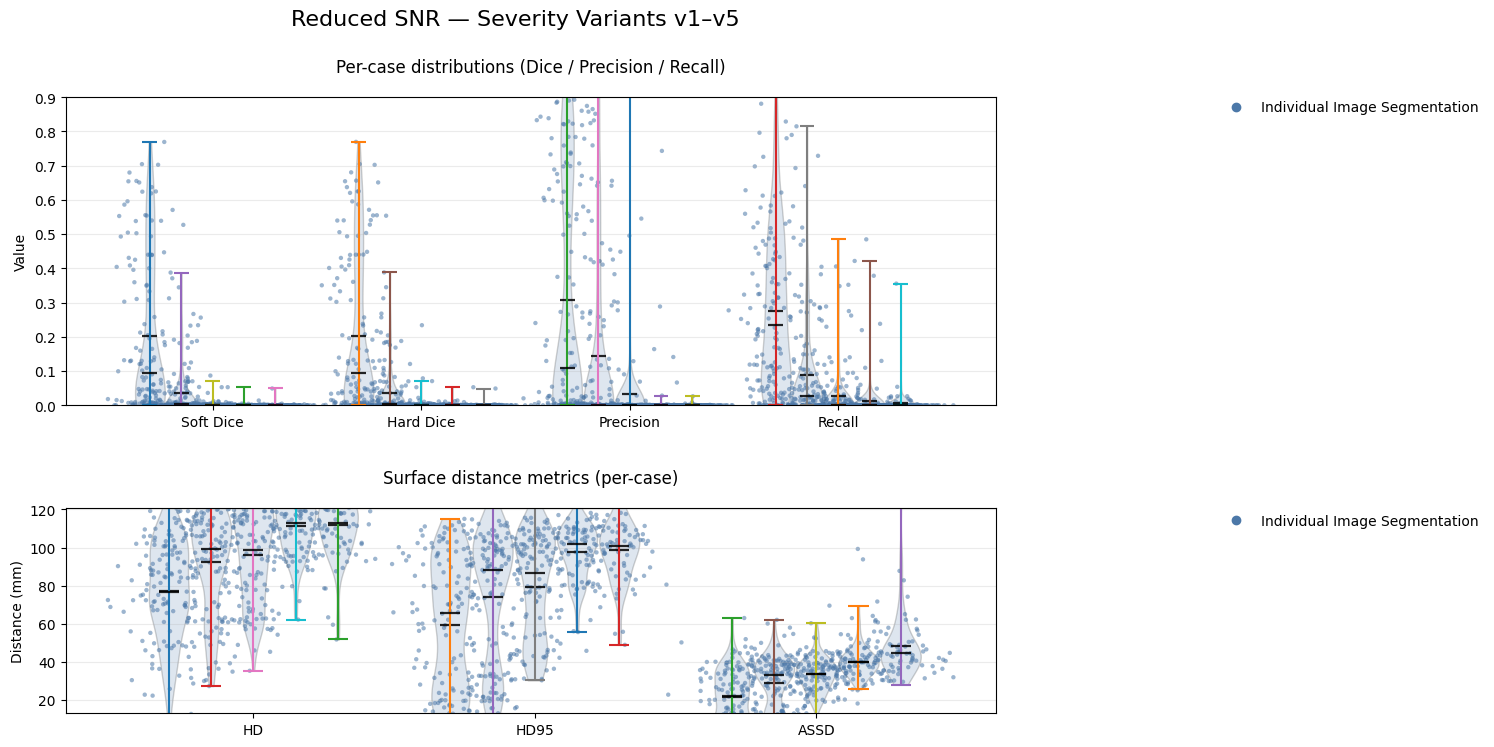

: 

In [ ]:
# ===== Severity gradient violin plots: Reduced SNR =====
from pathlib import Path

if not datasets:
    print("No datasets to plot — run Cell 2 first (and generate the variant images).")
else:
    pretty_violins_from_datasets(
        datasets,
        title='Reduced SNR — Severity Variants v1–v5',
        distance_units="mm",
        show_legend=True,
        save_path=Path('/home/rbielski/stroke_cleaned/ARC_ATLAS_Combined/ARC_ATLAS_Train_v3/runs/20260410_174944/test_eval/reducedsnr_all_variants_violins.png')
    )
